In [167]:
import sys,os
from dataclasses import dataclass
from pathlib import Path
repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, repo_root)
os.environ["CMB_ML_DATA"] = "/bigdata/cmb_project/data/"

from cmbml.sims.physics_instrument.noise_correlated import (
    NoiseCorrelatedManual,
    NoiseStationaryManual,
)
from cmbml.utils.physics_downgrade_by_alm import downgrade_noise_by_alm 
from cmbml.utils.planck_instrument import Detector # Needed for unit conversion context


In [168]:
import healpy as hp
from astropy.io import fits
import matplotlib.pyplot as plt
import numpy as np
from typing import List
import pysm3.units as u
%matplotlib inline 

In [169]:
NSIDE_OUT = 512              # Target output resolution
LMAX_OUT = 3 * NSIDE_OUT - 1 # Maximum multipole for ALM transforms
MC_SEED = 42                 # Monte Carlo Seed (noise realization number)
MAP_FIELDS = ["I"]           # Stokes parameter (Intensity only for now)
TARGET_UNIT = u.uK_CMB       # Target unit for all maps
TEST_FREQ = 143              # Example frequency (100 GHz, corresponding to the asset name)


## Useful funcs

In [170]:
@dataclass
class Record:
    name: str
    label: str
    sky: np.ndarray
    cl: np.ndarray
    color: str
    def __str__(self) -> str:
        return f"{self.name}: {self.label}, color: {self.color}"
    def __repr__(self) -> str:
        return self.__str__()


class Records:
    prop_cycle = plt.rcParams['axes.prop_cycle']
    mpl_colors = prop_cycle.by_key()['color']
    del prop_cycle  # clean up namespace
    def __init__(self):
        self.r = {}
    def get(self, id):
        if isinstance(id, str):
            return self.get_by_name(id)
        elif isinstance(id, int):
            return self.get_by_idx(id)
        else:
            raise ValueError(f"Invalid id {id}")
    def get_by_name(self, name):
        return self.r[name]
    def get_by_idx(self, idx):
        return list(self.r.values())[idx]
    def add(self, name, label, sky, dl):
        if name in self.r:
            new_color = self.get(name).color
        else:
            #fixed limited color issue
            color_index = len(self.r) % len(self.mpl_colors)
            new_color = self.mpl_colors[color_index]
        self.r[name] = Record(name, label, sky, dl, new_color)
    def add_record(self, record):
        record = Record(record.name, record.label, record.sky, record.dl, self.mpl_colors[len(self.r)])
        self.r[record.name] = record
    def get_labels(self, ids):
        return [self.get(id).label for id in ids]
    def get_colors(self, ids):
        return [self.get(id).color for id in ids]
    def get_skys(self, ids):
        return [self.get(id).sky for id in ids]
    def get_cls(self, ids):
        return [self.get(id).cl for id in ids]
    def get_many(self, ids):
        return [self.get(id) for id in ids]
    def get_all(self):
        return list(self.r.values())
    def __str__(self) -> str:
        if len(self.r) == 0:
            return "No records."
        for r in self.r.values():
            return "\n".join([str(r) for r in self.r.values()])
    def __repr__(self) -> str:
        return self.__str__()
    def __iter__(self):
        return iter(self.r.values())

def plot_ps(many_ps_list,
            labels, 
            # signal_type=None, 
            title=None, 
            x_low=None,
            x_high=None,
            y_low=None,
            y_high=None,
            colors=None,
            has_theory=False,
            loglog=True,
            scatter=True,
            helper_funcs=None):
    if not isinstance(many_ps_list, list):
        many_ps_list = [many_ps_list]
    if not isinstance(labels, list):
        labels = [labels]
    if not isinstance(colors, list):
        colors = [colors]
    # Set up for Noise specifically:
    y_label="$N_{\\ell}(\\mu K^2)$"
    x_label="$\\ell$"
    plt.figure()
    for i, (ps, label) in enumerate(zip(many_ps_list, labels)):
        if i == 0 and has_theory:  # Ideally, we could get a functional form for the noise. We've put a pin in this.
            style = '--'
            alpha = 1
        else:
            style = '-'
            alpha = 0.6
        color = colors[i] if colors is not None else None
        if scatter:
            ells = np.arange(len(ps))
            plt.scatter(x = ells, 
                        y = ps,
                        s=1,
                        label=label, 
                        color=color, 
                        alpha=alpha)
        else:
            plt.plot(ps, style, label=label, color=color, alpha=alpha)
    if isinstance(helper_funcs, list):
        for helper in helper_funcs:
            helper(plt)
    elif helper_funcs is not None:
        helper_funcs(plt)
    plt.xlabel(x_label)
    plt.ylabel(y_label)
    if loglog:
        plt.xscale('log')
        plt.yscale('log')
        if x_low is None:
            x_low = 1
        if y_low is None:
            y_low = 1
        plt.xlim([x_low, x_high])
        plt.ylim([y_low, y_high])
    else:
        plt.xlim([0, x_high])
        plt.ylim([0, y_high])
    plt.legend()
    plt.title(title)
    plt.show()

def make_histograms(records: Records, record_names_to_use: List[str], n_bins=100, force_lims=None):
    oal_min = None
    oal_max = None
    if force_lims is not None:
        oal_min, oal_max = force_lims
    else:
        for use_this in record_names_to_use:
            this_sky = records.get(use_this).sky
            this_min = this_sky.min()
            this_max = this_sky.max()
            oal_min = this_min if oal_min is None else min(oal_min, this_min)
            oal_max = this_max if oal_max is None else max(oal_max, this_max)
    bins = np.linspace(oal_min, oal_max, n_bins)

    plt.figure(figsize=(10, 6))
    for use_this in record_names_to_use:
        rec = records.get(use_this)
        # plt.hist(rec.sky, bins=bins, alpha=0.2, label=rec.label, color=rec.color)
        # plt.hist(rec.sky, bins=bins, alpha=0.2, label=rec.label, color=rec.color, edgecolor=rec.color)
        plt.hist(rec.sky, bins=bins, label=rec.label, color=rec.color, histtype='step')
    plt.legend()
    plt.title("Histogram of Noise Maps by Pixel Count")
    plt.show()

def get_units(fn):
    with fits.open(fn) as hdul:
        units = hdul[1].header["TUNIT1"]
    return units

## Assets paths

In [171]:
#1. Noise Model
NOISE_MODEL_PATH = f"/bigdata/cmb_project/data/Datasets/I_512_1550/NoiseModel/noise_model_{TEST_FREQ}_100.npz"

#2. Average Noise Map 
AVG_MAP_PATH = f"/bigdata/cmb_project/data/Datasets/I_512_1550/NoiseModel/avg_{TEST_FREQ}_I_100.fits"

#3. Standard Deviation Map (SD Map) -> stored as noiseCache
SD_MAP_PATH = f"/bigdata/cmb_project/data/Datasets/I_512_1550/Simulation_Working/Simulation_B_NoiseCache/{TEST_FREQ}_noise_sd_map.fits"

# initialize records
recs = Records()

## Load and prep assests

### Load noise model

In [172]:
print(f"Loading Noise model for {TEST_FREQ} GHz...")
noise_model_archive = np.load(NOISE_MODEL_PATH, allow_pickle=True)

Loading Noise model for 143 GHz...


In [173]:
noise_model_archive.files

['mean_ps', 'components', 'variance', 'maps_mean', 'maps_sd', 'maps_unit']

In [174]:
noise_model = {}
for key in noise_model_archive.files:
    noise_model[key] = noise_model_archive[key]
model_unit = u.Unit(str(noise_model["maps_unit"].item()))
if model_unit != TARGET_UNIT:
    print(f"Warning: Noise model unit ({model_unit}) differs from target unit ({TARGET_UNIT}).")


### Load SD maps

In [175]:
sd_map_quantity = None
print(f" Loading external SD map from: {SD_MAP_PATH}")
sd_map_raw = hp.read_map(SD_MAP_PATH)
sd_map_quantity = u.Quantity(sd_map_raw, unit=TARGET_UNIT)
current_nside = hp.get_nside(sd_map_quantity.value)
if current_nside != NSIDE_OUT:
    print(f"Degrading SD Map from NSIDE {current_nside} to {NSIDE_OUT}")
    sd_map_quantity = hp.ud_grade(sd_map_quantity, NSIDE_OUT)


 Loading external SD map from: /bigdata/cmb_project/data/Datasets/I_512_1550/Simulation_Working/Simulation_B_NoiseCache/143_noise_sd_map.fits


In [176]:
sd_map_quantity

<Quantity [4.720822 , 4.658311 , 4.672216 , ..., 5.039199 , 4.981154 ,
           4.9401717] uK_CMB>

### Load Avg maps


In [177]:
print(f"Loading Average Map from: {AVG_MAP_PATH}")
avg_map_raw = hp.read_map(AVG_MAP_PATH)

avg_map_quantity = u.Quantity(avg_map_raw, unit=TARGET_UNIT)

avg_map_quantity = downgrade_noise_by_alm(avg_map_quantity, NSIDE_OUT)

print("\nAssets prepared successfully.")

Loading Average Map from: /bigdata/cmb_project/data/Datasets/I_512_1550/NoiseModel/avg_143_I_100.fits

Assets prepared successfully.


## Test NoiseCorrelatedManual

In [178]:
correlated_generator = NoiseCorrelatedManual(
    nside_out=NSIDE_OUT, 
    lmax_out=LMAX_OUT, 
    map_fields=MAP_FIELDS
)
noise_corr_map = correlated_generator.get_noise_map(
    seed=MC_SEED,
    noise_model=noise_model,
    sd_map=sd_map_quantity
)

cl_corr = hp.anafast(noise_corr_map.value, lmax=LMAX_OUT)

recs.add(name="corr",
         label="Correlated Noise",
         sky=noise_corr_map.value,
         dl=cl_corr)

print(f"Generated Correlated Noise Map. Unit: {noise_corr_map.unit}")
print(f"Mean: {np.mean(noise_corr_map.value):.4f} {noise_corr_map.unit.name}")
print(f"Std Dev: {np.std(noise_corr_map.value):.4f} {noise_corr_map.unit.name}")


Generated Correlated Noise Map. Unit: uK_CMB
Mean: 0.0000 uK_CMB
Std Dev: 4.1389 uK_CMB


### Plotting Correlated PS

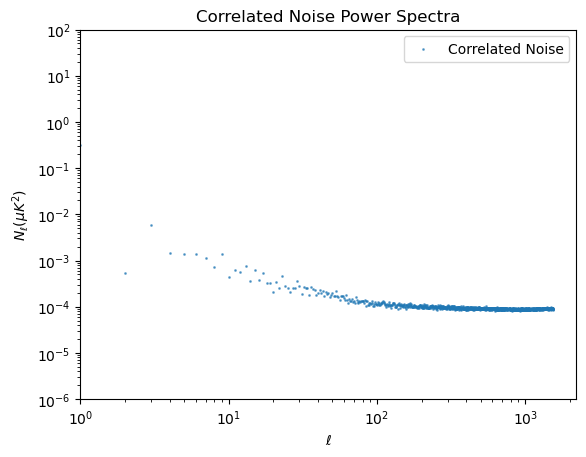

In [179]:
ps_list = recs.get_cls(['corr'])
labels = recs.get_labels(['corr'])
colors = recs.get_colors(['corr'])

plot_ps(ps_list,
        labels,
        title=f"Correlated Noise Power Spectra",
        # x_low=1,
        # x_high=3000,
        y_low=1e-6,    #set 1e2 for 857
        y_high=1e2,    #set 1e6 for 857
        colors=colors,
        has_theory=False,
        loglog=True,
        scatter=True)

## Test NoseStationaryManual

In [180]:
stat_generator = NoiseStationaryManual(
    nside_out=NSIDE_OUT, 
    lmax_out=LMAX_OUT, 
    map_fields=MAP_FIELDS
)
noise_stat_map = stat_generator.get_noise_map(
    seed=MC_SEED,
    noise_model=noise_model,
    sd_map=sd_map_quantity,
    avg_map=avg_map_quantity
)

cl_stat = hp.anafast(noise_stat_map.value, lmax=LMAX_OUT)

recs.add(name="stat",
         label="Stationary Noise",
         sky=noise_stat_map.value,
         dl=cl_stat)

print(f"Generated Stationary Noise Map. Unit: {noise_stat_map.unit}")
print(f"Mean: {np.mean(noise_stat_map.value):.4f} {noise_stat_map.unit.name}")
print(f"Std Dev: {np.std(noise_stat_map.value):.4f} {noise_stat_map.unit.name}")

Generated Stationary Noise Map. Unit: uK_CMB
Mean: -0.3719 uK_CMB
Std Dev: 4.2050 uK_CMB


### Plotting Stationary PS

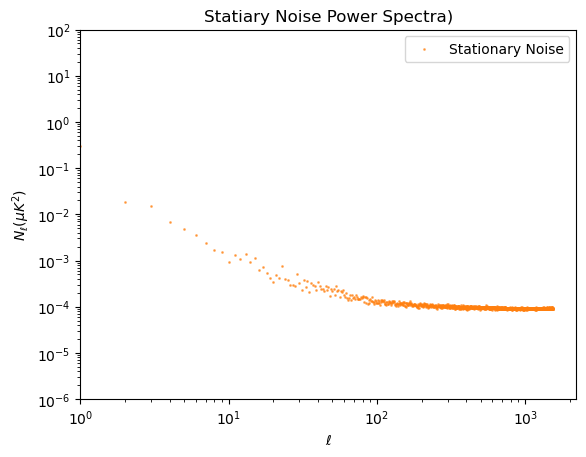

In [181]:
ps_list = recs.get_cls(['stat'])
labels = recs.get_labels(['stat'])
colors = recs.get_colors(['stat'])

plot_ps(ps_list,
        labels,
        title=f"Statiary Noise Power Spectra)",
        # x_low=1,
        # x_high=3000,
        y_low=1e-6,
        y_high=1e2,
        colors=colors,
        has_theory=False,
        loglog=True,
        scatter=True)

## Plotting them together

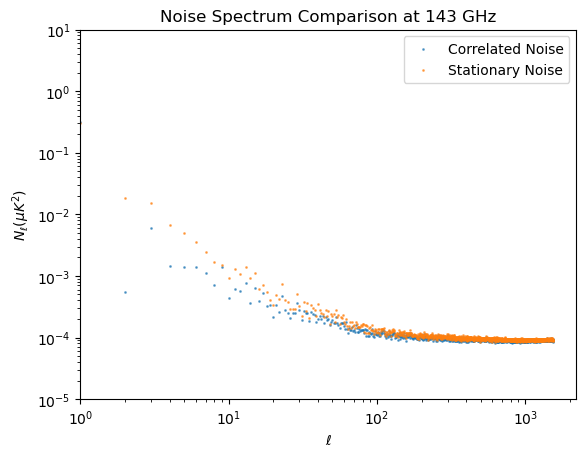

In [182]:
ps_list = recs.get_cls(['corr', 'stat'])
labels = recs.get_labels(['corr', 'stat'])
colors = recs.get_colors(['corr', 'stat'])

        # Call the user's provided plotting function
plot_ps(
    many_ps_list=ps_list,
    labels=labels, 
    colors=colors,
    title=f"Noise Spectrum Comparison at {TEST_FREQ} GHz",
    y_low=1e-5,  #1e-6,
    y_high=1e1,
    has_theory=False,
    loglog=True,
    scatter=True
    )
